# mathsteps - a guided tour

**mathsteps** solves maths problems *and shows every step*: linear algebra, root finding, interpolation,
integration, differentiation, and ODEs / BVPs. Every answer is **verified** against an independent
reference (NumPy / SciPy / SymPy).

This notebook installs the package from PyPI and runs every feature. **Runtime -> Run all** takes about a minute.

| # | Section | What you will see |
|---|---|---|
| 1 | The `Result` object | answer, exact form, steps, verification |
| 2 | Linear algebra | solve, determinant, inverse, LU, eigenvalues, Cramer, big systems |
| 3 | Root finding | four methods, convergence, warnings, real-world equations |
| 4 | Interpolation | Lagrange and Newton polynomials you can call like functions |
| 5 | Integration & differentiation | accuracy orders, round-off, error messages |
| 6 | Initial value problems | 5 methods, systems, second order, backwards |
| 7 | Boundary value problems | shooting and finite differences, with the whole profile |
| 8 | Verification | what `verified` means, and catching a wrong answer |
| 9 | Command line | the same solvers from a shell |

## 0. Setup

If Colab asks you to **restart the runtime** after the install (it sometimes does when it upgrades NumPy),
restart and continue from the next cell.

In [1]:
%pip install -q -U mathsteps

In [2]:
import math, sys, time, warnings
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt
import sympy
import mathsteps

sympy.init_printing()
print("mathsteps", mathsteps.__version__)
solvers = mathsteps.available_solvers()
print(len(solvers), "solvers:", ", ".join(solvers))

mathsteps 0.1.0
21 solvers: cofactor_determinant, cramers_rule, eigenvalues, gauss_jordan_inverse, gaussian_elimination, lu_decomposition, bisection, fixed_point, lagrange, newton_divided_differences, newton_raphson, numerical_diff, numerical_integration, secant, finite_difference, shooting, euler, heun, midpoint, rk4, rk45


In [3]:
# Plot style: one blue/orange/aqua/yellow palette in a fixed order, 2px lines, quiet grid.
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3de"
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 13,
    "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "lines.linewidth": 2, "legend.frameon": False, "font.size": 11, "figure.dpi": 110,
})


def end_label(ax, x, y, text, dy=0):
    """Direct label at the end of a line, in ink colour."""
    ax.annotate(text, (x, y), xytext=(6, dy), textcoords="offset points", va="center",
                fontsize=10, color=INK, annotation_clip=False)


def indent(text):
    return text.replace("\n", "\n          ")


def show_steps(result, limit=None):
    """Print the step-by-step explanation of a Result."""
    for i, s in enumerate(result.steps[:limit], 1):
        print(f"Step {i}: {s.description}")
        if s.before:
            print("   before:", indent(s.before))
        if s.after and s.after != s.before:
            print("   after: ", indent(s.after))

## 1. The `Result` object

Every function returns a `Result`. Here is a 3x3 linear system:

$$\begin{aligned} 2x + y - z &= 8 \\ -3x - y + 2z &= -11 \\ -2x + y + 2z &= -3 \end{aligned}$$

In [4]:
r = mathsteps.linear_system([[2, 1, -1], [-3, -1, 2], [-2, 1, 2]], [8, -11, -3])

print("answer   :", r.answer, "   <- a numpy array")
print("exact    :", r.exact, "   <- exact rationals (SymPy)")
print("verified :", r.verified, "   <- checked against numpy.linalg.solve")
print("solver   :", r.solver)
print("steps    :", len(r.steps))
print()
show_steps(r)

answer   : [ 2.  3. -1.]    <- a numpy array
exact    : [2, 3, -1]    <- exact rationals (SymPy)
verified : True    <- checked against numpy.linalg.solve
solver   : gaussian_elimination
steps    : 11

Step 1: Form the augmented matrix [A | b].
   before: [2  1  -1  8]
          [-3  -1  2  -11]
          [-2  1  2  -3]
Step 2: Swap row 0 with row 1 (partial pivoting, |-3| is largest in column 0).
   before: [2  1  -1  8]
          [-3  -1  2  -11]
          [-2  1  2  -3]
   after:  [-3  -1  2  -11]
          [2  1  -1  8]
          [-2  1  2  -3]
Step 3: Eliminate entry in row 1, column 0: R1 = R1 - (-2/3) * R0.
   before: [-3  -1  2  -11]
          [2  1  -1  8]
          [-2  1  2  -3]
   after:  [-3  -1  2  -11]
          [0  1/3  1/3  2/3]
          [-2  1  2  -3]
Step 4: Eliminate entry in row 2, column 0: R2 = R2 - (2/3) * R0.
   before: [-3  -1  2  -11]
          [0  1/3  1/3  2/3]
          [-2  1  2  -3]
   after:  [-3  -1  2  -11]
          [0  1/3  1/3  2/3]
          [0  5

`verified` is **three-valued**: `True` (checked and matches), `False` (checked and does *not* match) or
`None` (not checked - for example you passed `verify=False`). `None` is never reported as a pass.

## 2. Linear algebra

### 2.1 A circuit: Gaussian elimination
Three mesh currents in a circuit: resistance matrix **R** (ohms), source voltages **V**, solve `R I = V`.

In [5]:
R = [[10, -2, -3],
     [-2,  8, -1],
     [-3, -1,  9]]
V = [12, 0, 6]

r = mathsteps.linear_system(R, V)
print("mesh currents (A):", r.answer.round(4))
print("exact             :", r.exact)
print("verified          :", r.verified)
print("check R @ I - V   :", np.abs(np.array(R) @ r.answer - V).max())

mesh currents (A): [1.7085 0.5898 1.3017]
exact             : [504/295, 174/295, 384/295]
verified          : True
check R @ I - V   : 8.881784197001252e-16


### 2.2 Exact arithmetic
Elimination runs on exact fractions, so decimals like `0.1` are read as `1/10` (not the binary
approximation), and an ill-conditioned system - here the 8x8 **Hilbert matrix** - is solved without
round-off.

In [6]:
# 0.1 is exactly 1/10 here, so the answer is exactly [1, 2]
r = mathsteps.linear_system([[0.1, 0.2], [0.3, 0.4]], [0.5, 1.1])
print(r.answer, r.exact)

# Hilbert matrix: condition number ~ 1e10. Exact fractions in -> exact answer out.
n = 8
H = [[Fraction(1, i + j + 1) for j in range(n)] for i in range(n)]
b = [sum(row) for row in H]                    # chosen so the true solution is all ones
r = mathsteps.linear_system(H, b)
Hf = np.array(H, dtype=float)
print("true solution          : all ones")
print("mathsteps (exact)      : max error =", np.abs(r.answer - 1).max())
print("numpy.linalg.solve     : max error =", np.abs(np.linalg.solve(Hf, np.array(b, dtype=float)) - 1).max())
print("verified               :", r.verified)

[1. 2.] [1, 2]
true solution          : all ones
mathsteps (exact)      : max error = 0.0
numpy.linalg.solve     : max error = 3.4595712783414e-07
verified               : True


### 2.3 Cramer's rule, determinant, inverse, LU

In [7]:
r = mathsteps.cramers_rule(R, V)
print("Cramer's rule :", r.exact, "->", r.answer.round(4), "| verified:", r.verified)

# Vandermonde determinant = product of (x_j - x_i): a known closed form
xs = [1, 2, 3, 4, 5]
Vd = [[x ** k for k in range(5)] for x in xs]
r = mathsteps.determinant(Vd)
expected = int(np.prod([xs[j] - xs[i] for i in range(5) for j in range(i + 1, 5)]))
print("Vandermonde det:", r.answer, "| exact:", r.exact, "| formula:", expected, "| verified:", r.verified)

# The cofactor expansion is memoised, so even 12x12 is instant
M = [[(i * j + 1) if i != j else 5 for j in range(12)] for i in range(12)]
t0 = time.perf_counter()
r = mathsteps.determinant(M)
print(f"12x12 determinant: {r.exact}  ({time.perf_counter() - t0:.2f}s, verified={r.verified})")

Cramer's rule : [504/295, 174/295, 384/295] -> [1.7085 0.5898 1.3017] | verified: True
Vandermonde det: 288.0 | exact: 288 | formula: 288 | verified: True
12x12 determinant: -1943913207398400  (0.09s, verified=True)


In [8]:
# Inverse of the 4x4 Hilbert matrix: the exact inverse has integer entries
H4 = [[Fraction(1, i + j + 1) for j in range(4)] for i in range(4)]
r = mathsteps.inverse(H4)
print("verified:", r.verified, "| numeric answer is a", type(r.answer).__name__, r.answer.shape)
r.exact          # exact SymPy matrix

verified: True | numeric answer is a ndarray (4, 4)


⎡ 16   -120    240   -140 ⎤
⎢                         ⎥
⎢-120  1200   -2700  1680 ⎥
⎢                         ⎥
⎢240   -2700  6480   -4200⎥
⎢                         ⎥
⎣-140  1680   -4200  2800 ⎦

In [9]:
A = [[2, 1, 1], [4, -6, 0], [-2, 7, 2]]
r = mathsteps.lu(A)
P, L, U = r.answer
print("P @ A == L @ U :", np.allclose(P @ np.array(A), L @ U), "| verified:", r.verified)
print("L =\n", L.round(4))
print("U =\n", U.round(4))

P @ A == L @ U : True | verified: True
L =
 [[ 1.   0.   0. ]
 [ 0.5  1.   0. ]
 [-0.5  1.   1. ]]
U =
 [[ 4. -6.  0.]
 [ 0.  4.  1.]
 [ 0.  0.  1.]]


### 2.4 Eigenvalues and eigenvectors
The answer has the same layout as `numpy.linalg.eig`: `vectors[:, j]` is a unit eigenvector for `values[j]`.
When the characteristic polynomial factors into degree <= 2 pieces the eigenvalues are **exact**.

In [10]:
K = [[2, -1, 0], [-1, 2, -1], [0, -1, 2]]          # a chain of springs
r = mathsteps.eigenvalues(K)
values, vectors = r.answer
print("exact eigenvalues  :", r.exact[0])
print("numeric            :", values.round(6))
print("A @ V == V * values:", np.allclose(np.array(K) @ vectors, vectors * values))
print("verified           :", r.verified)

exact eigenvalues  : [2 - sqrt(2), 2, sqrt(2) + 2]
numeric            : [0.585786 2.       3.414214]
A @ V == V * values: True
verified           : True


Real data (here a **covariance matrix**) gives irrational eigenvalues. They are computed to 15 digits, and
the eigenvectors are the principal axes:

eigenvalues: [3.2497 0.097 ] | verified: True


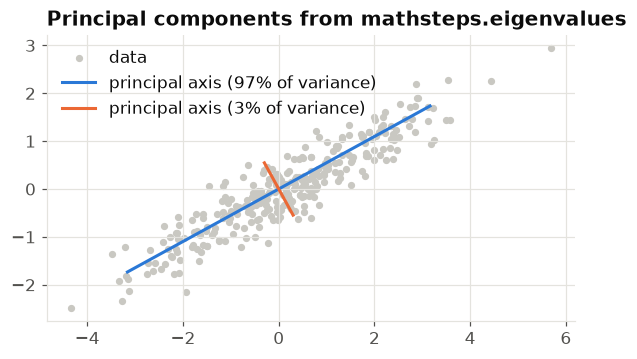

In [11]:
rng = np.random.default_rng(7)
data = rng.multivariate_normal([0, 0], [[3.0, 1.6], [1.6, 1.0]], size=300)
C = np.cov(data.T)

r = mathsteps.eigenvalues(C.tolist())
values, vectors = r.answer
order = np.argsort(values)[::-1]                       # largest variance first
share = values[order] / values.sum() * 100
print("eigenvalues:", values[order].round(4), "| verified:", r.verified)

fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.scatter(data[:, 0], data[:, 1], s=14, color="#c9c8c2", label="data", zorder=1)
for j, color in zip(order, (BLUE, ORANGE)):
    axis = vectors[:, j] * 2 * math.sqrt(values[j])
    ax.plot([-axis[0], axis[0]], [-axis[1], axis[1]], color=color, zorder=2,
            label=f"principal axis ({share[list(order).index(j)]:.0f}% of variance)")
ax.set_aspect("equal"); ax.set_title("Principal components from mathsteps.eigenvalues")
ax.legend(loc="upper left"); plt.show()

In [12]:
cases = {
    "identity (repeated eigenvalue)":     [[2, 0], [0, 2]],
    "defective (Jordan block)":           [[2, 1], [0, 2]],
    "rotation (complex eigenvalues)":     [[0, -1], [1, 0]],
    "Markov chain, decimal probabilities": [[0.9, 0.5], [0.1, 0.5]],
}
for name, M in cases.items():
    r = mathsteps.eigenvalues(M)
    values, vectors = r.answer
    print(f"{name:38s} values={np.round(values, 4)}  eigenvectors={vectors.shape[1]}  verified={r.verified}")

# Markov chain: the eigenvector for eigenvalue 1 is the long-run (stationary) distribution
values, vectors = mathsteps.eigenvalues([[0.9, 0.5], [0.1, 0.5]]).answer
v = vectors[:, int(np.argmin(np.abs(values - 1)))]
print("stationary distribution:", (v / v.sum()).round(4), " (exactly [5/6, 1/6])")

identity (repeated eigenvalue)         values=[2. 2.]  eigenvectors=2  verified=True
defective (Jordan block)               values=[2.]  eigenvectors=1  verified=True
rotation (complex eigenvalues)         values=[0.-1.j 0.+1.j]  eigenvectors=2  verified=True
Markov chain, decimal probabilities    values=[0.4 1. ]  eigenvectors=2  verified=True
stationary distribution: [0.8333 0.1667]  (exactly [5/6, 1/6])


Notice the **defective** matrix honestly reports *one* eigenvector (a 2x2 matrix cannot be diagonalised),
while the identity keeps *both* of its independent eigenvectors.

### 2.5 Big systems: the `detail` setting
Recording every row operation of a 40x40 elimination would produce ~800 steps. Large problems are
**summarised by default**; the answer is identical either way.

In [13]:
n = 40
A40 = [[((i * 7 + j * 3) % 11) + (20 if i == j else 0) for j in range(n)] for i in range(n)]
b40 = [1] * n

for detail in (None, "full", "none"):
    t0 = time.perf_counter()
    r = mathsteps.linear_system(A40, b40, detail=detail)
    label = "default (auto)" if detail is None else detail
    print(f"detail={label:15s} steps={len(r.steps):4d}   {time.perf_counter() - t0:5.2f}s   verified={r.verified}")
show_steps(mathsteps.linear_system(A40, b40), limit=4)

detail=default (auto)  steps=  43    0.59s   verified=True


detail=full            steps= 821    2.88s   verified=True


detail=none            steps=   4    1.21s   verified=True


Step 1: Form the augmented matrix [A | b]. (40 x 41; detail='summary', matrix snapshots omitted)
Step 2: Column 0: pivot 20; cleared 36 entries below it.
Step 3: Column 1: pivot 579/20; cleared 38 entries below it.
Step 4: Column 2: pivot 5427/193; cleared 37 entries below it.


## 3. Root finding

**Kepler's equation** $E - e\sin E = M$ gives a planet's position along its orbit. With eccentricity
$e = 0.3$ and $M = 1$ we solve it four ways.

In [14]:
from scipy.optimize import brentq
kepler = "E - 0.3*sin(E) - 1.0"
reference = brentq(lambda E: E - 0.3 * math.sin(E) - 1.0, 0, 3)

runs = {
    "newton_raphson": mathsteps.root(kepler, variable="E", method="newton", x0=1.0),
    "secant":         mathsteps.root(kepler, variable="E", method="secant", x0=0.5, x1=2.0),
    "bisection":      mathsteps.root(kepler, variable="E", method="bisection", a=0, b=3),
    "fixed_point":    mathsteps.root("1.0 + 0.3*sin(E)", variable="E", method="fixed_point", x0=1.0),
}
print(f"{'method':16s}{'root':>16s}{'iterations':>12s}{'verified':>10s}{'converged':>11s}")
for name, r in runs.items():
    iterations = sum(1 for s in r.steps if s.data.get("iter"))
    print(f"{name:16s}{r.answer:16.10f}{iterations:12d}{str(r.verified):>10s}{str(r.converged):>11s}")
print("scipy.optimize.brentq:", f"{reference:.10f}")

method                      root  iterations  verified  converged
newton_raphson      1.2880913132           5      True       True
secant              1.2880913132           6      True       True
bisection           1.2880913132          36      True       True
fixed_point         1.2880913132          10      True       True
scipy.optimize.brentq: 1.2880913132


Every iteration is recorded in `result.steps`, so convergence can be plotted straight from the steps. Newton
and secant converge superlinearly; fixed-point converges linearly; bisection halves the bracket each time.

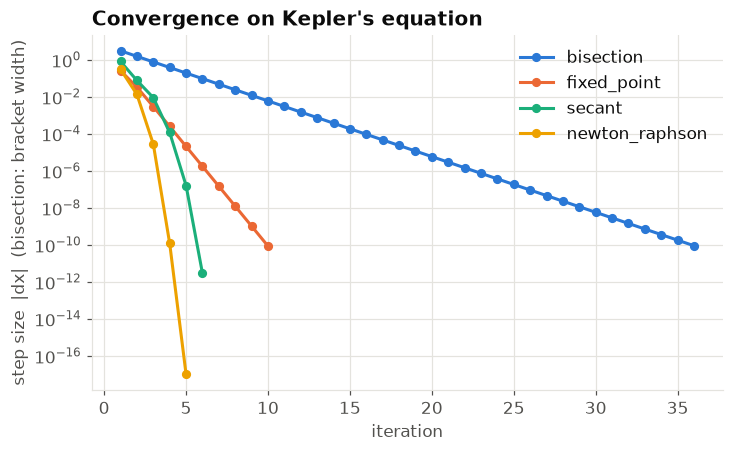

In [15]:
def step_sizes(result):
    out = []
    for s in result.steps:
        d = s.data
        if "iter" not in d:
            continue
        out.append(abs(d["b"] - d["a"]) if "a" in d else d["delta"])     # bisection: bracket width
    return np.array(out)

fig, ax = plt.subplots(figsize=(7.4, 4.2))
styles = [("bisection", BLUE), ("fixed_point", ORANGE), ("secant", AQUA), ("newton_raphson", YELLOW)]
for name, color in styles:
    y = step_sizes(runs[name]); x = np.arange(1, len(y) + 1)
    ax.plot(x, np.maximum(y, 1e-17), color=color, marker="o", markersize=5, label=name)
ax.set_yscale("log"); ax.set_xlabel("iteration"); ax.set_ylabel("step size  |dx|  (bisection: bracket width)")
ax.set_title("Convergence on Kepler's equation"); ax.legend(loc="upper right"); plt.show()

### 3.1 Convergence is reported, never silent
`cos(x)` has a slow fixed point (|g'| is about 0.67), so 50 iterations cannot reach a tolerance of 1e-10.
You get a `ConvergenceWarning`, `converged=False`, and the last step says so.

In [16]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    r = mathsteps.root("cos(x)", method="fixed_point", x0=0.5)          # default max_iter=50
print("converged:", r.converged, "| answer:", round(r.answer, 8))
print("warning  :", str(caught[0].message)[:110], "...")
print("last step:", r.steps[-1].description)

r = mathsteps.root("cos(x)", method="fixed_point", x0=0.5, max_iter=200)
print("\nwith max_iter=200 -> converged:", r.converged, "| answer:", round(r.answer, 12), "| verified:", r.verified)

converged: False | answer: 0.73908513
last step: Did NOT converge: reached max_iter=50 with |delta x| > tol = 1e-10; returning last iterate.

with max_iter=200 -> converged: True | answer: 0.73908513325 | verified: True


### 3.2 Real-world equations

In [17]:
# Internal rate of return of the cash flows -1000, +300, +400, +500
npv = "-1000 + 300/(1+r) + 400/(1+r)**2 + 500/(1+r)**3"
irr = mathsteps.root(npv, variable="r", method="bisection", a=0, b=1)
print(f"IRR                      = {irr.answer * 100:.4f} %      verified={irr.verified}")

# Colebrook-White pipe friction factor (relative roughness 0.0002, Reynolds number 1e5)
colebrook = "1/sqrt(f) + 2*log(0.0002/3.7 + 2.51/(100000*sqrt(f)))/log(10)"
f = mathsteps.root(colebrook, variable="f", method="secant", x0=0.02, x1=0.03)
print(f"Colebrook friction factor = {f.answer:.6f}        verified={f.verified}")

# Van der Waals CO2 at 300 K and 10 atm: molar volume V (litres/mol)
R_, a_, b_, T, P = 0.082057, 3.640, 0.04267, 300.0, 10.0
vdw = f"({P} + {a_}/V**2)*(V - {b_}) - {R_ * T}"
V_m = mathsteps.root(vdw, variable="V", method="newton", x0=2.0)
print(f"van der Waals molar volume = {V_m.answer:.5f} L/mol   verified={V_m.verified}  (ideal gas: {R_ * T / P:.5f})")

IRR                      = 8.8963 %      verified=True


Colebrook friction factor = 0.019005        verified=True
van der Waals molar volume = 2.35245 L/mol   verified=True  (ideal gas: 2.46171)


### 3.3 Friendly input handling
Common formats just work (`x^2`, `2x`, `ln`), and mistakes give a clear message instead of a stack trace.

In [18]:
print("x^2 - 2      ->", round(mathsteps.root("x^2 - 2", method="newton", x0=1).answer, 10))
print("2x - 4       ->", mathsteps.root("2x - 4", method="newton", x0=1).answer)
print("ln(x) - 1    ->", round(mathsteps.root("ln(x) - 1", method="newton", x0=2).answer, 10), "(= e)")
print()

mistakes = {
    "constant not substituted (k)": lambda: mathsteps.root("k*x - 3", method="newton", x0=1),
    "'e' instead of E":              lambda: mathsteps.root("e**x - 2", method="newton", x0=1),
    "bracket without sign change":   lambda: mathsteps.root("x**2 + 1", method="bisection", a=0, b=1),
    "zero derivative":               lambda: mathsteps.root("x**3", method="newton", x0=0),
    "garbage expression":            lambda: mathsteps.root("x**$", method="newton", x0=1),
    "unknown method":                lambda: mathsteps.root("x - 1", method="magic", x0=1),
}
for name, call in mistakes.items():
    try:
        call()
    except ValueError as exc:
        print(f"{name:30s} -> ValueError: {str(exc)[:88]}")

x^2 - 2      ->

 1.4142135624
2x - 4       -> 2.0
ln(x) - 1    -> 2.7182818285 (= e)

constant not substituted (k)   -> ValueError: Unknown symbol(s) ['k'] in 'k*x - 3'. Only x may appear; substitute numbers for any cons
'e' instead of E               -> ValueError: Unknown symbol(s) ['e'] in 'e**x - 2' (use E for Euler's number). Only x may appear; sub
bracket without sign change    -> ValueError: Bisection requires f(a) and f(b) to have opposite signs; got f(0.0)=1.0, f(1.0)=2.0.
zero derivative                -> ValueError: f'(x) = 0 at x = 0.0; Newton-Raphson cannot continue.
garbage expression             -> ValueError: Could not parse 'x**$' as a math expression: invalid syntax (<string>, line 1)
unknown method                 -> ValueError: No solver registered for problem type 'root_finding'. Registered: ['cofactor_determinant


## 4. Interpolation

US census data, 1950-2000 (millions). The result is a **callable polynomial**, evaluated in exact arithmetic
so abscissae like 1975 lose no digits to cancellation.

In [19]:
years = [1950, 1960, 1970, 1980, 1990, 2000]
pop = [151.3, 179.3, 203.3, 226.5, 248.7, 281.4]

lag = mathsteps.lagrange(list(zip(years, pop)))
newt = mathsteps.newton_divided_differences(list(zip(years, pop)))
p, q = lag.answer, newt.answer

print("degree             :", p.degree)
print("population in 1975 :", round(p(1975), 4), "(Lagrange)", round(q(1975), 4), "(Newton)")
print("same polynomial    :", np.allclose(p(np.linspace(1950, 2000, 50)), q(np.linspace(1950, 2000, 50))))
print("passes through data:", np.allclose(p(years), pop), "| verified:", lag.verified, newt.verified)
print("one step per basis polynomial:", len(lag.steps), "steps (Lagrange);", len(newt.steps), "steps (divided differences)")
show_steps(newt, limit=3)

degree             : 5
population in 1975 : 215.1098 (Lagrange) 215.1098 (Newton)
same polynomial    : True
passes through data: True | verified: True True
one step per basis polynomial: 8 steps (Lagrange); 7 steps (divided differences)
Step 1: Newton divided-differences interpolation through 6 points: (1950, 1513/10), (1960, 1793/10), (1970, 2033/10), (1980, 453/2), (1990, 2487/10), (2000, 1407/5).
   after:  order 0 coefficients: ['1513/10', '1793/10', '2033/10', '453/2', '2487/10', '1407/5']
Step 2: Order 1 divided differences: f[x0,x1] = 14/5, f[x1,x2] = 12/5, f[x2,x3] = 58/25, f[x3,x4] = 111/50, f[x4,x5] = 327/100.
   after:  order 1 = ['14/5', '12/5', '58/25', '111/50', '327/100']
Step 3: Order 2 divided differences: f[x0,x1,x2] = -1/50, f[x1,x2,x3] = -1/250, f[x2,x3,x4] = -1/200, f[x3,x4,x5] = 21/400.
   after:  order 2 = ['-1/50', '-1/250', '-1/200', '21/400']


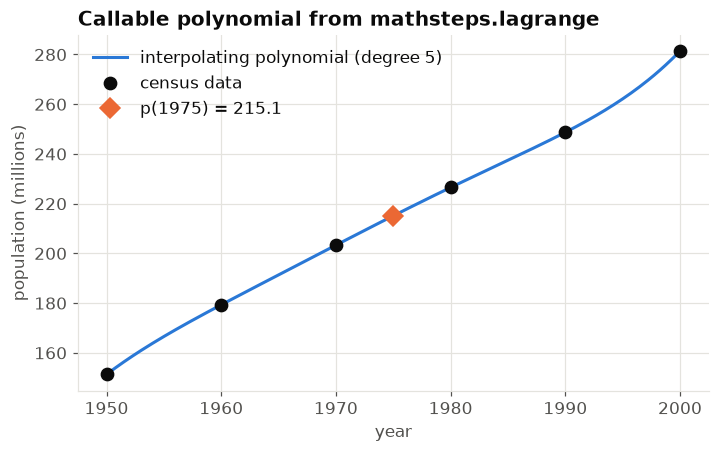

In [20]:
grid = np.linspace(1950, 2000, 200)
fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.plot(grid, p(grid), color=BLUE, label="interpolating polynomial (degree 5)")
ax.plot(years, pop, "o", color=INK, markersize=8, label="census data")
ax.plot([1975], [p(1975)], "D", color=ORANGE, markersize=9, label=f"p(1975) = {p(1975):.1f}")
ax.set_xlabel("year"); ax.set_ylabel("population (millions)"); ax.set_title("Callable polynomial from mathsteps.lagrange")
ax.legend(loc="upper left"); plt.show()

## 5. Integration and differentiation

### 5.1 The normal distribution
$\Phi(1.96) - \tfrac12 = \int_0^{1.96} \frac{e^{-x^2/2}}{\sqrt{2\pi}}\,dx \approx 0.475$

In [21]:
from scipy.integrate import quad
f = "exp(-x**2/2)/sqrt(2*pi)"
reference = quad(lambda x: math.exp(-x * x / 2) / math.sqrt(2 * math.pi), 0, 1.96)[0]

print(f"{'rule':14s}{'n':>5s}{'answer':>16s}{'error':>12s}{'verified':>10s}")
for method in ("trapezoidal", "simpson"):
    for n in (10, 40):
        r = mathsteps.integrate(f, a=0, b=1.96, n=n, method=method)
        print(f"{method:14s}{n:5d}{r.answer:16.10f}{abs(r.answer - reference):12.2e}{str(r.verified):>10s}")
print("scipy quad reference:", f"{reference:.10f}")
print()
show_steps(mathsteps.integrate(f, a=0, b=1.96, n=40, method="simpson"))

rule              n          answer       error  verified


trapezoidal      10    0.4746356100    3.66e-04      True
trapezoidal      40    0.4749791872    2.29e-05      True


simpson          10    0.4750012765    8.28e-07      True
simpson          40    0.4750021018    3.10e-09      True
scipy quad reference: 0.4750021049



Step 1: Numerical integration (simpson) of f(x) = sqrt(2)*exp(-x**2/2)/(2*sqrt(pi)) on [0.0, 1.96] with n = 40, h = 0.049.
   after:  n = 40, h = 0.049
Step 2: Composite formula: integral ≈ h/3 * (y0 + yn + 4*sum_odd + 2*sum_even), h = (b - a) / n = 0.049; sum over 40 sub-intervals.
   after:  integral ≈ 0.4750021017553038
Step 3: Exact integral: ∫ f dx from 0.0 to 1.96 = erf(0.98*sqrt(2))/2 ≈ 0.47500210485177957. Absolute error ≈ 3.096e-09.
   after:  integral = 0.47500210485177957


### 5.2 Accuracy orders
Doubling the number of intervals should cut the trapezoid error by 4x (order 2) and Simpson's by 16x (order 4).

trapezoidal  error ratios per doubling: [4.03 4.01 4.   4.   4.  ]
simpson      error ratios per doubling: [16.94 16.22 16.06 16.01 16.  ]


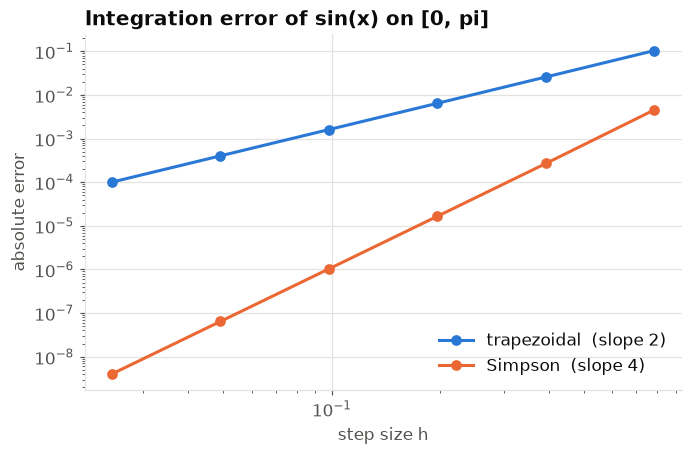

In [22]:
ns = [4, 8, 16, 32, 64, 128]
err = {m: [abs(mathsteps.integrate("sin(x)", a=0, b=math.pi, n=n, method=m, verify=False).answer - 2.0) for n in ns]
       for m in ("trapezoidal", "simpson")}
for m in err:
    ratios = [err[m][i] / err[m][i + 1] for i in range(len(ns) - 1)]
    print(f"{m:12s} error ratios per doubling: {np.round(ratios, 2)}")

h = [math.pi / n for n in ns]
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.loglog(h, err["trapezoidal"], "o-", color=BLUE, markersize=6, label="trapezoidal  (slope 2)")
ax.loglog(h, err["simpson"], "o-", color=ORANGE, markersize=6, label="Simpson  (slope 4)")
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_xlabel("step size h"); ax.set_ylabel("absolute error"); ax.set_title("Integration error of sin(x) on [0, pi]")
ax.legend(loc="lower right"); plt.show()

### 5.3 Endpoints must be finite
`sin(x)/x` is undefined at 0. Instead of silently returning `nan`, you get a clear error; start at a tiny `a`.

In [23]:
try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)          # NumPy's own 0/0 warning; the error below says it better
        mathsteps.integrate("sin(x)/x", a=0, b=math.pi, n=100, method="simpson")
except ValueError as exc:
    print("ValueError:", str(exc)[:100])

r = mathsteps.integrate("sin(x)/x", a=1e-12, b=math.pi, n=100, method="simpson")
print("a = 1e-12 ->", round(r.answer, 8), "(true value Si(pi) = 1.85193705...)  verified:", r.verified)

ValueError: The integrand f(0.0) (sampled at an endpoint or node) is not finite (nan); the function is undefined


a = 1e-12 -> 1.85193705 (true value Si(pi) = 1.85193705...)  verified: True


### 5.4 Numerical derivatives: truncation vs round-off
Smaller `h` reduces the formula's truncation error, until round-off takes over. The central difference is
second-order accurate; forward is first-order.

best central step h = 1e-05 (error 2.9e-11); below that round-off dominates
h=1e-3 central: 3.756048954207003 | exact: 3.7560492270947274 | verified: True


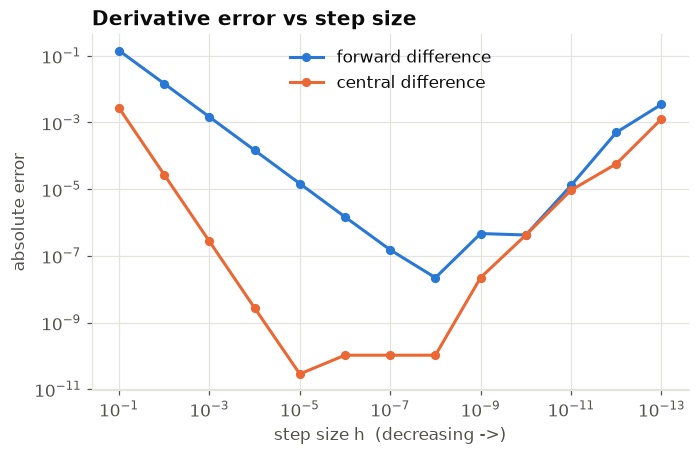

In [24]:
x0 = 1.0
exact = math.e * (math.sin(x0) + math.cos(x0))            # d/dx [e^x sin x]
hs = [10.0 ** -k for k in range(1, 14)]
errs = {m: [abs(mathsteps.differentiate("exp(x)*sin(x)", x=x0, h=h, method=m, verify=False).answer - exact) for h in hs]
        for m in ("forward", "central")}

best = hs[int(np.argmin(errs["central"]))]
print(f"best central step h = {best:.0e} (error {min(errs['central']):.1e}); below that round-off dominates")
r = mathsteps.differentiate("exp(x)*sin(x)", x=x0, h=1e-3, method="central")
print("h=1e-3 central:", r.answer, "| exact:", exact, "| verified:", r.verified)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.loglog(hs, errs["forward"], "o-", color=BLUE, markersize=5, label="forward difference")
ax.loglog(hs, errs["central"], "o-", color=ORANGE, markersize=5, label="central difference")
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.invert_xaxis(); ax.set_xlabel("step size h  (decreasing ->)"); ax.set_ylabel("absolute error")
ax.set_title("Derivative error vs step size"); ax.legend(loc="upper center"); plt.show()

## 6. Initial value problems

`ivp` supports Euler, Heun, midpoint, RK4 and adaptive RK45, for **one equation or a system**, forwards or
backwards, and `ivp_second_order` handles `y'' = f(x, y, y')`.

### 6.1 Newton's law of cooling
$\dfrac{dT}{dt} = -0.07\,(T - 20)$, $T(0) = 90\,^\circ\mathrm{C}$. Name the variables however you like.

In [25]:
cooling = dict(f_expr="-0.07*(T-20)", variable="t", function="T", y0=90.0, x_end=30.0)
exact = 20 + 70 * math.exp(-0.07 * 30)

print(f"{'method':10s}{'h':>6s}{'T(30)':>14s}{'error':>12s}{'steps':>7s}{'verified':>10s}")
for m in ("euler", "heun", "midpoint", "rk4"):
    r = mathsteps.ivp(h=3.0, method=m, **cooling)
    print(f"{m:10s}{3.0:6.1f}{r.answer:14.8f}{abs(r.answer - exact):12.2e}{len(r.details['x']) - 1:7d}{str(r.verified):>10s}")
r = mathsteps.ivp(method="rk45", **cooling)
print(f"{'rk45':10s}{'auto':>6s}{r.answer:14.8f}{abs(r.answer - exact):12.2e}{len(r.details['x']) - 1:7d}{str(r.verified):>10s}")
print(f"{'exact':10s}{'':>6s}{exact:14.8f}")

method         h         T(30)       error  steps  verified
euler        3.0   26.62779326    1.94e+00     10      True
heun         3.0   28.72822126    1.56e-01     10      True
midpoint     3.0   28.72822126    1.56e-01     10      True
rk4          3.0   28.57229767    3.48e-04     10      True
rk45        auto   28.57194998    2.10e-11    102      True
exact              28.57194998


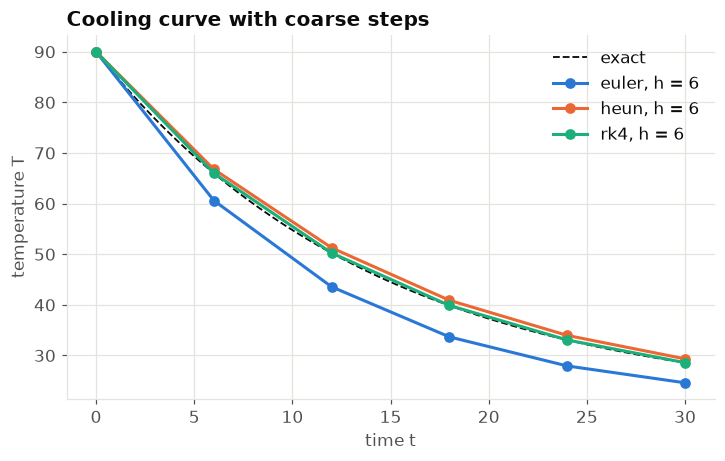

In [26]:
fig, ax = plt.subplots(figsize=(7.6, 4.3))
tt = np.linspace(0, 30, 200)
ax.plot(tt, 20 + 70 * np.exp(-0.07 * tt), color=INK, linestyle="--", linewidth=1.2, label="exact")
for m, color in (("euler", BLUE), ("heun", ORANGE), ("rk4", AQUA)):
    r = mathsteps.ivp(h=6.0, method=m, verify=False, **cooling)               # deliberately coarse steps
    ax.plot(r.details["x"], r.details["y"][:, 0], "o-", color=color, markersize=6, label=f"{m}, h = 6")
ax.set_xlabel("time t"); ax.set_ylabel("temperature T"); ax.set_title("Cooling curve with coarse steps")
ax.legend(loc="upper right"); plt.show()

Halving `h` should divide the error by 2 (Euler), 4 (Heun, midpoint) and 16 (RK4):

In [27]:
print(f"{'method':10s}{'order':>7s}  error ratio when h is halved (h = 3, 1.5, 0.75)")
for m, order in (("euler", 1), ("heun", 2), ("midpoint", 2), ("rk4", 4)):
    e = [abs(mathsteps.ivp(h=h, method=m, verify=False, **cooling).answer - exact) for h in (3.0, 1.5, 0.75)]
    print(f"{m:10s}{order:7d}  {e[0] / e[1]:6.2f}, {e[1] / e[2]:6.2f}      (expected about {2 ** order})")

method      order  error ratio when h is halved (h = 3, 1.5, 0.75)
euler           1    2.03,   2.01      (expected about 2)
heun            2    4.36,   4.17      (expected about 4)
midpoint        2    4.36,   4.17      (expected about 4)
rk4             4   17.47,  16.72      (expected about 16)


### 6.2 When a method fails, you are told
Explicit Euler on the stiff equation $y' = -1000\,y$ is unstable with `h = 0.01`. The result blows up, and
verification **refuses to pass it**. A small enough step is fine.

In [28]:
bad = mathsteps.ivp("-1000*y", y0=1, x_end=1, h=0.01, method="euler")
print(f"h = 0.01   -> answer {bad.answer:.3e}   verified = {bad.verified}   (the true value is about 0)")
good = mathsteps.ivp("-1000*y", y0=1, x_end=1, h=0.0005, method="euler")
print(f"h = 0.0005 -> answer {good.answer:.3e}   verified = {good.verified}")
print("bad step sizes are rejected:", end=" ")
try:
    mathsteps.ivp("y", h=-0.1, x_end=1)
except ValueError as exc:
    print(exc)

h = 0.01   -> answer 2.656e+95   verified = False   (the true value is about 0)


h = 0.0005 -> answer 0.000e+00   verified = True


bad step sizes are rejected: Step size h must be positive; got h = -0.1.


### 6.3 Systems of equations: predator and prey
Lotka-Volterra: $\dot u = 1.1u - 0.4uw$, $\dot w = 0.1uw - 0.4w$. Pass **one expression per unknown**.
The whole trajectory is in `result.details`.

state at t = 20: [10.2141  1.3338] | verified against scipy solve_ivp: True


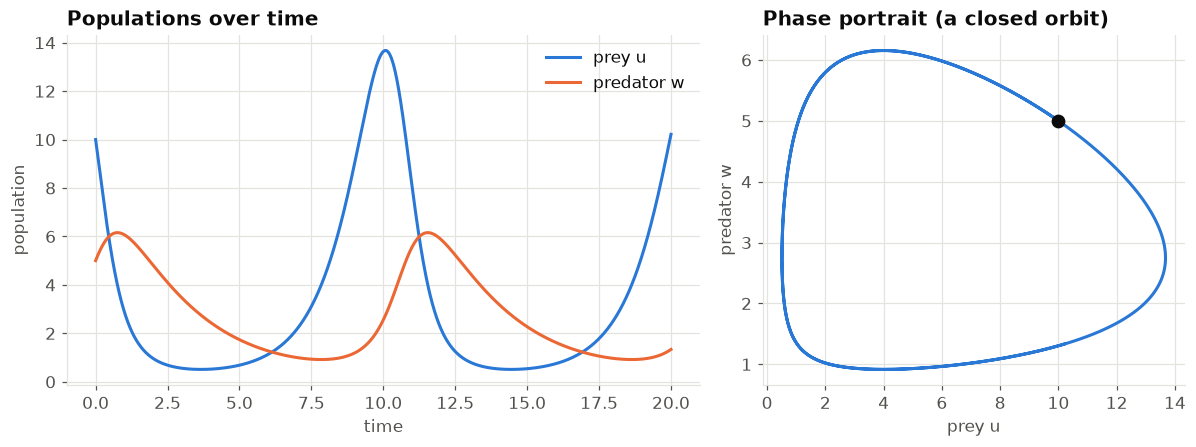

In [29]:
r = mathsteps.ivp(["1.1*u - 0.4*u*w", "0.1*u*w - 0.4*w"], variable="t", function=["u", "w"],
                  y0=[10, 5], x_end=20, h=0.005)
t, y = r.details["x"], r.details["y"]
print("state at t = 20:", r.answer.round(4), "| verified against scipy solve_ivp:", r.verified)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.5, 1]})
a1.plot(t, y[:, 0], color=BLUE, label="prey u"); a1.plot(t, y[:, 1], color=ORANGE, label="predator w")
a1.set_xlabel("time"); a1.set_ylabel("population"); a1.set_title("Populations over time"); a1.legend(loc="upper right")
a2.plot(y[:, 0], y[:, 1], color=BLUE); a2.plot(y[0, 0], y[0, 1], "o", color=INK, markersize=8)
a2.set_xlabel("prey u"); a2.set_ylabel("predator w"); a2.set_title("Phase portrait (a closed orbit)")
plt.tight_layout(); plt.show()

### 6.4 Second-order equations
A damped spring, $x'' = -4x - 0.5x'$, written with `x` and `xp` (for $x'$). Internally it becomes the system
$x' = v,\; v' = -4x - 0.5v$.

[x(20), x'(20)] = [-0.001949 -0.012422] | verified: True


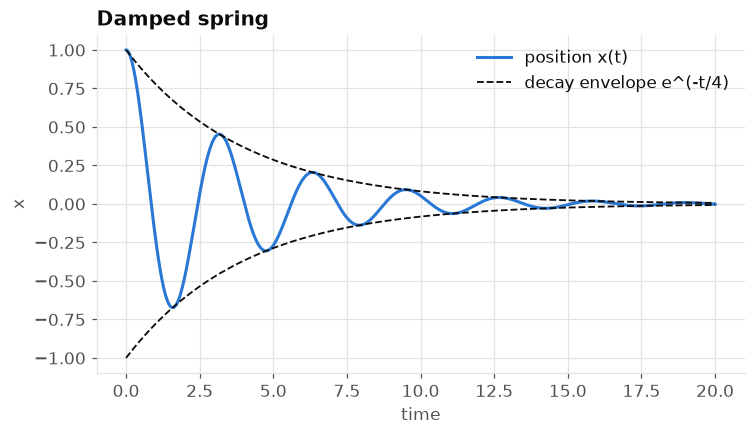

pendulum energy drift over 10 s: 1.81e-12 | verified: True


In [30]:
r = mathsteps.ivp_second_order("-4*x - 0.5*xp", variable="t", function="x", y0=1, dy0=0, x_end=20, h=0.01)
t, y = r.details["x"], r.details["y"]
print("[x(20), x'(20)] =", r.answer.round(6), "| verified:", r.verified)

fig, ax = plt.subplots(figsize=(7.6, 4.0))
ax.plot(t, y[:, 0], color=BLUE, label="position x(t)")
ax.plot(t, np.exp(-0.25 * t), color=INK, linestyle="--", linewidth=1.2, label="decay envelope e^(-t/4)")
ax.plot(t, -np.exp(-0.25 * t), color=INK, linestyle="--", linewidth=1.2)
ax.set_xlabel("time"); ax.set_ylabel("x"); ax.set_title("Damped spring"); ax.legend(loc="upper right"); plt.show()

# Nonlinear pendulum: theta'' = -(g/L) sin(theta). Energy should stay constant.
g_over_l = 9.81
p = mathsteps.ivp_second_order(f"-{g_over_l}*sin(th)", variable="t", function="th", y0=1.0, dy0=0.0, x_end=10, h=0.001)
th, om = p.details["y"][:, 0], p.details["y"][:, 1]
energy = 0.5 * om ** 2 - g_over_l * np.cos(th)
print("pendulum energy drift over 10 s:", f"{np.ptp(energy):.2e}", "| verified:", p.verified)

### 6.5 Backwards in time, and step-count control
Give `x_end < x0` to integrate backwards. Run the oscillator forward, then back, and you land on the start.

In [31]:
osc = dict(variable="t", function=["x", "v"])
fwd = mathsteps.ivp(["v", "-4*x"], y0=[1, 0], x_end=2, h=0.005, **osc)
back = mathsteps.ivp(["v", "-4*x"], y0=list(fwd.answer), x0=2, x_end=0, h=0.005, **osc)
print("forward  to t=2:", fwd.answer.round(6))
print("backward to t=0:", back.answer.round(8), "(started at [1, 0])  verified:", back.verified)
print(back.steps[0].description[:105], "...")
print()

# 10 000 RK4 steps: the default summarises, but the whole trajectory is always kept
for detail in (None, "full", "none"):
    r = mathsteps.ivp("-0.5*y", y0=1, x_end=20, h=0.002, method="rk4", detail=detail, verify=False)
    label = "default (auto)" if detail is None else detail
    print(f"detail={label:15s} steps recorded={len(r.steps):6d}   trajectory points={len(r.details['x'])}   y(20)={r.answer:.10f}")
show_steps(mathsteps.ivp("-0.5*y", y0=1, x_end=20, h=0.002, method="rk4", verify=False), limit=5)

forward  to t=2:

 [-0.653644  1.513605]
backward to t=0: [1. 0.] (started at [1, 0])  verified: True
RK4 for dx/dt = v, dv/dt = -4*x, x(2.0) = -0.6536436211140555, v(2.0) = 1.5136049901759063, integrating b ...



detail=default (auto)  steps recorded=     8   trajectory points=10001   y(20)=0.0000453999


detail=full            steps recorded= 10002   trajectory points=10001   y(20)=0.0000453999


detail=none            steps recorded=     3   trajectory points=10001   y(20)=0.0000453999


Step 1: RK4 for dy/dx = -0.5*y, y(0.0) = 1.0, integrating to x = 20.0 with h = 0.002 (10000 steps).
   after:  x0 = 0.0, y0 = 1.0
Step 2: Step 1: x = 0.0, y = 1.0; k1 = -0.5, k2 = -0.49975, k3 = -0.499750125, k4 = -0.499500249875; y_new = y + h/6*(k1+2k2+2k3+k4) = 0.999000499833375; x_new = 0.002.
   before: x = 0.0, y = 1.0
   after:  x = 0.002, y = 0.999000499833375
Step 3: Step 2: x = 0.002, y = 0.999000499833375; k1 = -0.4995002499166875, k2 = -0.49925049979172914, k3 = -0.49925062466679165, k4 = -0.49900099929202074; y_new = y + h/6*(k1+2k2+2k3+k4) = 0.9980019986673331; x_new = 0.004.
   before: x = 0.002, y = 0.999000499833375
   after:  x = 0.004, y = 0.9980019986673331
Step 4: Step 3: x = 0.004, y = 0.9980019986673331; k1 = -0.49900099933366654, k2 = -0.4987514988339997, k3 = -0.4987516235842495, k4 = -0.4985022477100823; y_new = y + h/6*(k1+2k2+2k3+k4) = 0.997004495503373; x_new = 0.006.
   before: x = 0.004, y = 0.9980019986673331
   after:  x = 0.006, y = 0.997004495503373
S

## 7. Boundary value problems

Both solvers return the **whole solution** on a grid, with the grid in `result.details["x"]`.

### 7.1 A cooling fin (shooting method)
A metal fin satisfies $T'' = 0.01\,(T - 20)$ with $T(0) = 100$ and $T(10) = 50$. Shooting guesses the
slope $T'(0)$ and corrects it with the secant method until the right end matches.

converged: True | verified against scipy solve_bvp: True
slope T'(0) = -7.951528   (analytic -7.951528)
max error over the whole profile: 1.14e-13


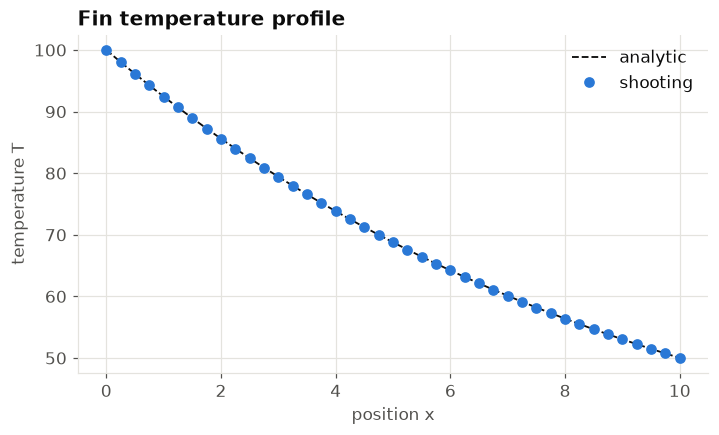

In [32]:
m = 0.1
A_, B_ = np.linalg.solve([[1, 1], [math.exp(m * 10), math.exp(-m * 10)]], [80, 30])    # analytic solution
r = mathsteps.bvp_shooting("0.01*(y-20)", y_left=100, y_right=50, x_end=10, h=0.01, s0=-10, s1=0)

x, T = r.details["x"], r.answer
exact_T = 20 + A_ * np.exp(m * x) + B_ * np.exp(-m * x)
print("converged:", r.converged, "| verified against scipy solve_bvp:", r.verified)
print(f"slope T'(0) = {r.details['slope']:.6f}   (analytic {m * (A_ - B_):.6f})")
print("max error over the whole profile:", f"{np.abs(T - exact_T).max():.2e}")

fig, ax = plt.subplots(figsize=(7.4, 4.0))
ax.plot(x, exact_T, color=INK, linestyle="--", linewidth=1.2, label="analytic")
ax.plot(x[::25], T[::25], "o", color=BLUE, markersize=6, label="shooting")
ax.set_xlabel("position x"); ax.set_ylabel("temperature T"); ax.set_title("Fin temperature profile"); ax.legend(); plt.show()

### 7.2 Convection-diffusion (finite differences)
$-y'' + 10\,y' = 0$, $y(0)=0$, $y(1)=1$ has the sharp boundary layer
$y = (e^{10x}-1)/(e^{10}-1)$. The method is second-order: refining the grid shrinks the error about 4x per doubling.

n =   9 interior points: max error = 3.45e-02   verified = True
n =  49 interior points: max error = 1.23e-03   verified = True


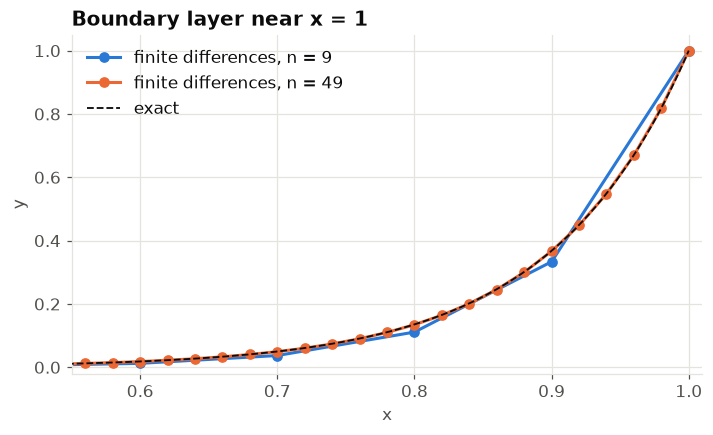

heated rod max error: 1.2e-14 | verified: True


In [33]:
exact_fn = lambda x: (np.exp(10 * x) - 1) / (np.exp(10) - 1)
fig, ax = plt.subplots(figsize=(7.4, 4.0))
for n, color in ((9, BLUE), (49, ORANGE)):
    r = mathsteps.bvp_finite_difference(p_expr="10", q_expr="0", r_expr="0", beta=1.0, n=n)
    x = r.details["x"]
    print(f"n = {n:3d} interior points: max error = {np.abs(r.answer - exact_fn(x)).max():.2e}   verified = {r.verified}")
    ax.plot(x, r.answer, "o-", color=color, markersize=6, label=f"finite differences, n = {n}", zorder=2)
xs = np.linspace(0, 1, 400)
ax.plot(xs, exact_fn(xs), color=INK, linestyle="--", linewidth=1.2, label="exact", zorder=3)   # on top, so the gap is visible
ax.set_xlim(0.55, 1.01); ax.set_ylim(-0.02, 1.05)                                              # zoom on the boundary layer
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("Boundary layer near x = 1"); ax.legend(loc="upper left"); plt.show()

# -y'' = 50 (a rod with uniform heat generation): exact answer 25 x (1 - x)
r = mathsteps.bvp_finite_difference(q_expr="0", r_expr="50", n=19)
print("heated rod max error:", f"{np.abs(r.answer - 25 * r.details['x'] * (1 - r.details['x'])).max():.1e}", "| verified:", r.verified)

### 7.3 A nonlinear problem (Bratu)
$y'' = -e^{y}$, $y(0)=y(1)=0$ has no closed form in $x$, but the slope at 0 is known:
$y'(0) = \theta \tanh(\theta/4)$ where $\theta = \sqrt{2}\cosh(\theta/4)$.

slope y'(0) = 0.549353   known value = 0.549353
peak of the profile = 0.1405   converged = True   verified = True


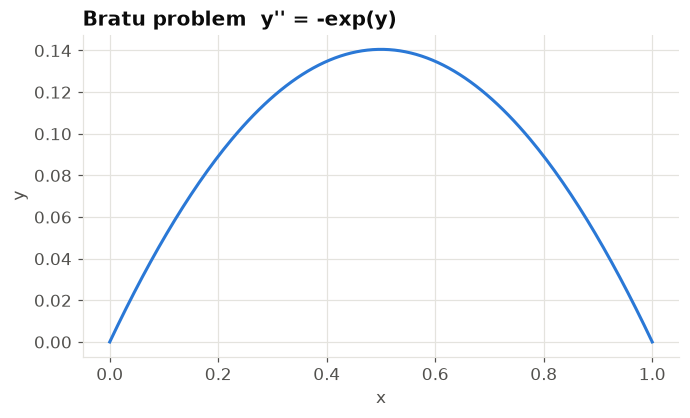

In [34]:
theta = brentq(lambda t: t - math.sqrt(2) * math.cosh(t / 4), 0.1, 3)
r = mathsteps.bvp_shooting("-exp(y)", y_left=0, y_right=0, x_end=1, h=0.005, s0=0.3, s1=0.8, tol=1e-9)
print(f"slope y'(0) = {r.details['slope']:.6f}   known value = {theta * math.tanh(theta / 4):.6f}")
print(f"peak of the profile = {r.answer.max():.4f}   converged = {r.converged}   verified = {r.verified}")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(r.details["x"], r.answer, color=BLUE)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_title("Bratu problem  y'' = -exp(y)"); plt.show()

## 8. Verification

Every solver is checked against an **independent** reference. Numerical methods are *supposed* to differ
from the true answer by their truncation error, so each tolerance is derived from that error: a correct
result passes, a wrong one does not.

In [35]:
from mathsteps.verify import verify_problem

r = mathsteps.integrate("sin(x)", a=0, b=math.pi, n=100, method="simpson")
print("correct answer      :", r.answer, "-> verified =", r.verified)
print("answer off by 0.1%  :", r.answer * 1.001, "-> verified =", verify_problem(r.problem, r.answer * 1.001))
print("verify=False        : verified =", mathsteps.integrate("sin(x)", a=0, b=math.pi, n=100, verify=False).verified, "(not checked)")

# Other families: tamper with the answer and the check fails
lu = mathsteps.determinant([[1, 2], [3, 4]])
print("determinant -2 vs 5 :", verify_problem(lu.problem, lu.exact), "vs", verify_problem(lu.problem, 5))
fd = mathsteps.bvp_finite_difference(q_expr="0", r_expr="50", n=19)
wrong = fd.answer.copy(); wrong[7] += 1e-3
print("BVP solution, one point moved by 0.001:", verify_problem(fd.problem, fd.answer), "vs", verify_problem(fd.problem, wrong))

correct answer      : 2.000000010824504 -> verified = True
answer off by 0.1%  : 2.0020000108353284 -> verified = False
verify=False        : verified = None (not checked)
determinant -2 vs 5 : True vs False
BVP solution, one point moved by 0.001: True vs False


### A scoreboard of all 21 solvers
One representative problem for each solver. `verified` is the independent check; `converged` appears only for
iterative methods.

In [36]:
A3 = [[4, 1, 0], [1, 3, 1], [0, 1, 2]]
pts = [(0, 1), (1, 2), (2, 5), (3, 10)]
ode = dict(f_expr="-2*x*y", y0=1, x_end=2)
suite = [
    mathsteps.linear_system(A3, [1, 2, 3]),
    mathsteps.inverse(A3),
    mathsteps.determinant(A3),
    mathsteps.lu(A3),
    mathsteps.eigenvalues(A3),
    mathsteps.cramers_rule(A3, [1, 2, 3]),
    mathsteps.root("x**3 - x - 2", method="bisection", a=1, b=2),
    mathsteps.root("x**3 - x - 2", method="newton", x0=1.5),
    mathsteps.root("x**3 - x - 2", method="secant", x0=1, x1=2),
    mathsteps.root("cos(x)", method="fixed_point", x0=0.5, max_iter=200),
    mathsteps.lagrange(pts),
    mathsteps.newton_divided_differences(pts),
    mathsteps.differentiate("sin(x)", x=1.0),
    mathsteps.integrate("sin(x)", a=0, b=math.pi, n=100, method="simpson"),
    mathsteps.ivp(h=0.05, method="euler", **ode),
    mathsteps.ivp(h=0.05, method="heun", **ode),
    mathsteps.ivp(h=0.05, method="midpoint", **ode),
    mathsteps.ivp(h=0.05, method="rk4", **ode),
    mathsteps.ivp(method="rk45", **ode),
    mathsteps.bvp_shooting("sin(x) - y", x_end=1),
    mathsteps.bvp_finite_difference(q_expr="1", r_expr="x", beta=1.0, n=19),
]
print(f"{'solver':28s}{'verified':>10s}{'converged':>11s}{'steps':>7s}")
for r in suite:
    print(f"{r.solver:28s}{str(r.verified):>10s}{str(r.converged):>11s}{len(r.steps):7d}")
assert sorted(r.solver for r in suite) == sorted(mathsteps.available_solvers()), "every solver is covered"
print("\nAll", len(suite), "solvers covered; verified:", sum(r.verified is True for r in suite), "of", len(suite))

solver                        verified  converged  steps
gaussian_elimination              True       None      8
gauss_jordan_inverse              True       None     10
cofactor_determinant              True       None      2
lu_decomposition                  True       None      5
eigenvalues                       True       None      6
cramers_rule                      True       None      5
bisection                         True       True     72
newton_raphson                    True       True      7
secant                            True       True     11
fixed_point                       True       True     60
lagrange                          True       None      6
newton_divided_differences        True       None      5
numerical_diff                    True       None      3
numerical_integration             True       None      3
euler                             True       None     42
heun                              True       None     42
midpoint                       

## 9. The command line

Installing the package also installs a `mathsteps` command. Inside a notebook we call it with
`python -m mathsteps` so it works regardless of `PATH`.

In [37]:
import subprocess, json, pathlib

def cli(*args, tail=6):
    out = subprocess.run([sys.executable, "-m", "mathsteps", *args], capture_output=True, text=True)
    lines = (out.stdout + out.stderr).strip().splitlines()
    print("$ mathsteps " + " ".join(args))
    print("\n".join(lines[-tail:]))
    print()

cli("--version")
cli("linear-system", "--A", "2 1; 1 3", "--b", "3 5", tail=3)
cli("eigen", "--A", "2 0; 0 3", tail=7)
cli("root", "--function", "x**3 - x - 2", "--method", "newton", "--x0", "1.5", tail=2)
cli("solve", "x**2 - 4 = 0", tail=2)

$ mathsteps --version
mathsteps 0.1.0



$ mathsteps linear-system --A 2 1; 1 3 --b 3 5
Final answer: [0.8, 1.4]
Exact: [4/5, 7/5]
Verification: PASS



$ mathsteps eigen --A 2 0; 0 3
 [0., 1.]]
Exact: ([2, 3], {2: [Matrix([
[1],
[0]])], 3: [Matrix([
[0],
[1]])]})
Verification: PASS



$ mathsteps root --function x**3 - x - 2 --method newton --x0 1.5
Final answer: 1.5213797068045676
Verification: PASS



$ mathsteps solve x**2 - 4 = 0
Final answer: 2.0
Verification: PASS



In [38]:
# ODE system and backwards integration from the shell
cli("ivp", "--f-expr", "v; -4*x", "--function", "x v", "--y0", "1 0", "--variable", "t", "--x-end", "3", "--h", "0.01", tail=2)
cli("ivp", "--f-expr", "y", "--y0", "2.718281828459045", "--x0", "1", "--x-end", "0", "--h", "0.01", tail=2)
cli("bvp", "--method", "finite_difference", "--q-expr", "0", "--r-expr", "50", "--n", "9", tail=2)
cli("integrate", "--function", "sin(x)", "--a", "0", "--c", "3.141592653589793", "--n", "100", "--method", "simpson", tail=2)
cli("linear-system", "--A", "1 2; 2 4", "--b", "1 2", tail=2)       # a clear one-line error, not a traceback

$ mathsteps ivp --f-expr v; -4*x --function x v --y0 1 0 --variable t --x-end 3 --h 0.01
Final answer: [0.9601702843, 0.5588310117]
Verification: PASS



$ mathsteps ivp --f-expr y --y0 2.718281828459045 --x0 1 --x-end 0 --h 0.01
Final answer: 1.0000000000840314
Verification: PASS



$ mathsteps bvp --method finite_difference --q-expr 0 --r-expr 50 --n 9
Final answer: [0.  , 2.25, 4.  , 5.25, 6.  , 6.25, 6.  , 5.25, 4.  , 2.25, 0.  ]
Verification: PASS



$ mathsteps integrate --function sin(x) --a 0 --c 3.141592653589793 --n 100 --method simpson
Final answer: 2.000000010824504
Verification: PASS



$ mathsteps linear-system --A 1 2; 2 4 --b 1 2
Error: Matrix is singular (zero pivot in column 1); no unique solution exists.



In [39]:
# Problems can also live in JSON files; `verify` exits with 0 (PASS), 1 (FAIL) or 2 (NOT CHECKED)
problem = {"type": "root_finding", "method": "newton_raphson", "function": "cos(x) - x",
           "variable": "x", "x0": 0.5, "tol": 1e-12, "max_iter": 50}
pathlib.Path("problem.json").write_text(json.dumps(problem))
cli("solve", "problem.json", tail=2)
code_ = subprocess.run([sys.executable, "-m", "mathsteps", "verify", "problem.json"], capture_output=True, text=True)
print("verify ->", code_.stdout.strip(), "(exit code", code_.returncode, ")")
cli("list-solvers", tail=21)

$ mathsteps solve problem.json
Final answer: 0.7390851332151607
Verification: PASS



verify -> PASS (exit code 0 )


$ mathsteps list-solvers
- cofactor_determinant
- cramers_rule
- eigenvalues
- gauss_jordan_inverse
- gaussian_elimination
- lu_decomposition
- bisection
- fixed_point
- lagrange
- newton_divided_differences
- newton_raphson
- numerical_diff
- numerical_integration
- secant
- finite_difference
- shooting
- euler
- heun
- midpoint
- rk4
- rk45



## 10. Summary

| Function | Answer | Highlights |
|---|---|---|
| `linear_system`, `cramers_rule` | `ndarray` (+ exact rationals) | exact arithmetic, step summaries for big systems |
| `determinant`, `inverse`, `lu` | `float` / `ndarray` / `(P, L, U)` | memoised cofactors, exact inverse |
| `eigenvalues` | `(values, vectors)` like NumPy | exact when possible, full eigenspaces, complex values |
| `root` | `float` | bisection, Newton, secant, fixed-point; `converged` + warning |
| `lagrange`, `newton_divided_differences` | callable polynomial | exact evaluation, `p.expr`, `p.coefficients` |
| `integrate`, `differentiate` | `float` | trapezoid / Simpson; forward / backward / central |
| `ivp`, `ivp_second_order` | `y(x_end)` + `details` | systems, backwards, 5 methods |
| `bvp_shooting`, `bvp_finite_difference` | `y` on a grid + `details` | whole profile, slope |

Every `Result` carries `.answer`, `.exact`, `.details`, `.steps`, `.verified`, `.converged` and `.problem`.

### Try your own
Edit and re-run:

In [40]:
# Your turn: change the problem and look at the steps.
r = mathsteps.root("x**3 - 2*x - 5", method="newton", x0=2.0)        # Wallis' classic cubic
print("root:", r.answer, "| verified:", r.verified, "| converged:", r.converged)
show_steps(r, limit=4)

root: 2.0945514815423265 | verified: True | converged: True
Step 1: Newton-Raphson on f(x) = x**3 - 2*x - 5, f'(x) = 3*x**2 - 2, starting at x0 = 2.0.
   after:  x0 = 2.0
Step 2: Iteration 1: x = 2.0, f(x) = -1.0, f'(x) = 10.0; x_new = x - f(x)/f'(x) = 2.1; |delta x| = 0.10000000000000009.
   before: x = 2.0
   after:  x = 2.1
Step 3: Iteration 2: x = 2.1, f(x) = 0.06100000000000083, f'(x) = 11.23; x_new = x - f(x)/f'(x) = 2.094568121104185; |delta x| = 0.005431878895814979.
   before: x = 2.1
   after:  x = 2.094568121104185
Step 4: Iteration 3: x = 2.094568121104185, f(x) = 0.0001857231732707021, f'(x) = 11.16164684183775; x_new = x - f(x)/f'(x) = 2.094551481698199; |delta x| = 1.6639405985952038e-05.
   before: x = 2.094568121104185
   after:  x = 2.094551481698199


---
**mathsteps** on PyPI: <https://pypi.org/project/mathsteps/> - source and issues:
<https://github.com/Stacktern/mathSteps>